## Project1 : Marketing Campaigns Analysis 

In [6]:
print("======================== Analyzing Marketing Campaigns data Using Python : Created by @Pooja Khaire =========================")

======================== Analyzing Marketing Campaigns data Using Python : Created by @Pooja Khaire =========================


## Problem Objective: 
To perform exploratory data analysis and hypothesis testing to gain a better understanding of the various factors that contribute to customer acquisition.  

Target variable(s):

    Response → accepted latest campaign (main acquisition signal)
    AcceptedCmp1–5 → historical campaign behavior

## Table of Content :
    1. Data Collection & Inspection
    2. Data Cleaning & Preprocessing
        - Clean malformed Input  -> Income values
        - prevent crashes from unseen data
        - Handling NaN
    3. Feture Engineering
        - New Feature Creation
        - Encoding
        - Heatmap - corr
        -corr with response
    4. Hypothesis Testing
    5. Visualization

In [131]:
# Importing Libraries
import pandas as pd
import numpy as np
import datetime

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Hypothesis Test
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu

# set overall cols and rows to be display
pd.set_option('display.max_columns', None)

#Ignore warnings
import warnings
warnings.filterwarnings(action='ignore')

##  1. Data Gathering & Inspection
The dataset contains customer-level marketing campaign information


In [10]:
#Used df name for simplicity as only one main dataset is used in the project.
marketing_data = pd.read_csv('Dataset/marketing_data.csv')
print(marketing_data.shape)

(2240, 28)


In [11]:
marketing_data.head()
# df[list(df.iloc[:,:-8].columns) + list(np.sort(df.iloc[:,-8:-3].columns)) + list(df.iloc[:,-3:].columns)]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


In [12]:
# To check an entire information of the data in one place like- Not Null values, dtypes, shape, memory usage.
marketing_data.info()
# only income col has null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [14]:
# Statistical summary of numerical data
marketing_data.describe()

# Each row has unique id,

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
# Statistical summary of categorical data
marketing_data.describe(include=object)

,Education,Marital_Status,Income,Dt_Customer,Country
count,2240,2240,2216,2240,2240
unique,5,8,1974,663,8
top,Graduation,Married,"$7,500.00",8/31/12,SP
freq,1127,864,12,12,1095


In [17]:
marketing_data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

## 2. Data CLeaning and Preprocessing

In [18]:
# Create a copy of origional df
df = marketing_data.copy()

In [19]:
# Dt_Customer and Income

#df['Dt_Customer'].str.split('/').apply(lambda x:x[0]).sort_values(ascending=False)
#df['Dt_Customer'].apply(lambda x:datetime.datetime.strptime(x,"%m/%d/%y"))
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer']) #yyyy-mm-dd

In [20]:
# Income col has space at both side need to be trim
df.columns = df.columns.str.strip()

# pd.to_numeric is the specialized function for safe conversion
# Regex removes EVERYTHING except digits and the decimal point
# errors='coerce': This is a "Safe Cast." If a row contains something completely non-numeric (like the word "Unknown"), it will turn it into NaN, prevent code crashing.

#to_numeric : best for big data but malformed data convert to nan, vectorized -> suited for the current use case
#pydantic : USed for application, best for system reliability , object oriented, . It is designed to be a contract between two systems (like your Frontend and your Backend)
df['Income'] = pd.to_numeric(df['Income'].str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

• Income values for a few customers are missing. Perform missing value imputation. Assume that the customers with similar education and marital status make the same yearly income, on average. You may have to clean the data before performing this. For data cleaning, look into the categories of education and marital status. 

In [21]:
print(f"{df['Education'].unique()}\n")
print(df['Marital_Status'].unique())

['Graduation' 'PhD' '2n Cycle' 'Master' 'Basic']

['Divorced' 'Single' 'Married' 'Together' 'Widow' 'YOLO' 'Alone' 'Absurd']


In [22]:
# Missing Value Imputation
df.isna().mean()*100 # Display Missing values in percentage

# Drops columns where more than 70% of values are missing
# limit = len(df) * 0.7
# df = df.dropna(thresh=limit, axis=1)

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Response               0.000000
Complain               0.000000
Country                0.000000
dtype: float64

In [23]:
#Show which Education–Marital_Status combinations have missing Income and how many
income_nan_df = df[df['Income'].isna()]
nan_counts_df = (
    income_nan_df
    .groupby(['Education', 'Marital_Status'])
    .size()
    .reset_index(name='missing_income_count')
)

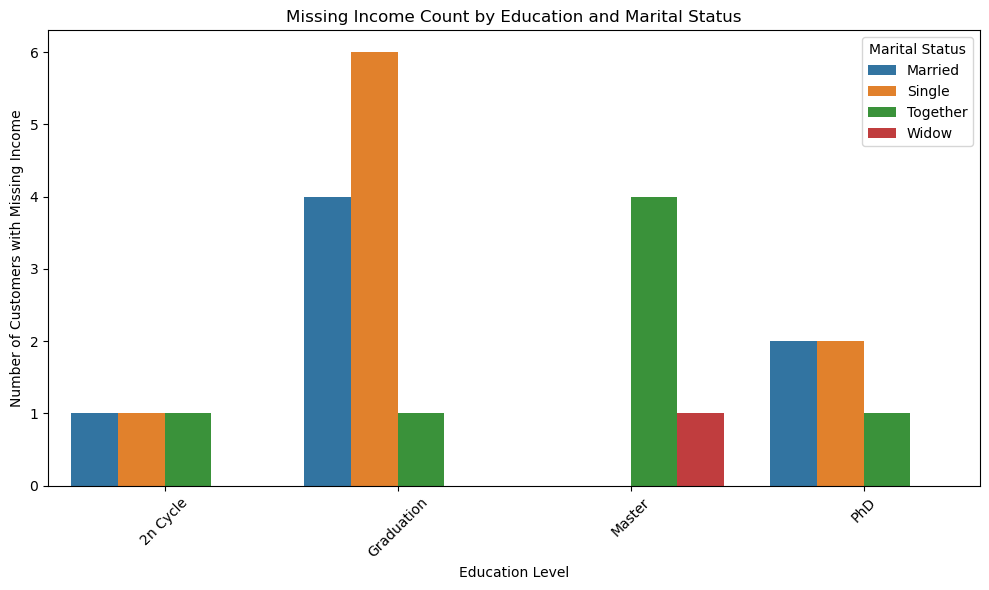

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=nan_counts_df,
    x='Education',
    y='missing_income_count',
    hue='Marital_Status'
)

plt.title('Missing Income Count by Education and Marital Status')
plt.ylabel('Number of Customers with Missing Income')
plt.xlabel('Education Level')
plt.xticks(rotation=45)
plt.legend(title='Marital Status')

plt.tight_layout()
plt.show()

In [26]:
df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

In [30]:
# Where Income is NaN, replace it with the group’s mean income
df['Income'] = df['Income'].fillna(
    df.groupby(['Education', 'Marital_Status'])['Income']
    .transform('mean')
)

In [31]:
df['Income'].isna().sum()

np.int64(0)

# 3. Feature Engineering

•	Create variables to populate the total number of children, age, and total spending. 

Hint: From the number of purchases through the three channels, people can derive the total purchases.


In [34]:
# Household responsibility level
df['total_children'] = df['Kidhome'] + df['Teenhome']

In [35]:
# Different age groups respond differently to campaigns
CURRENT_YEAR = 2025
df['age'] = CURRENT_YEAR - df['Year_Birth']
min(df['age']),max(df['age'])

(29, 132)

In [37]:
#Overall customer value, Helps segment high-value vs low-value customers
spend_cols = [
       'MntWines', 'MntFruits', 'MntMeatProducts', 
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

df['total_spend'] = df[spend_cols].sum(axis=1)

In [38]:
#Customer engagement level, Indicates purchasing frequency regardless of channel
purchase_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases', 
    'NumStorePurchases'
]

df['total_purchases'] = df[purchase_cols].sum(axis=1)

In [39]:
# Avg spend per purchase
df['avg_spend_per_purchase'] = df['total_spend'] / df['total_purchases']
df['avg_spend_per_purchase'] = df['avg_spend_per_purchase'].fillna(0)

In [40]:
df[['total_children','age','total_spend','total_purchases','avg_spend_per_purchase']].describe()

,total_children,age,total_spend,total_purchases,avg_spend_per_purchase
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,0.950446,56.194196,605.798214,12.537054,inf
std,0.751803,11.984069,602.249288,7.205741,NaN
min,0.000000,29.000000,5.000000,0.000000,2.666667
25%,0.000000,48.000000,68.750000,6.000000,13.000000
50%,1.000000,55.000000,396.000000,12.000000,29.890110
75%,1.000000,66.000000,1045.500000,18.000000,50.194231
max,3.000000,132.000000,2525.000000,32.000000,inf


In [41]:
df.groupby('Response')[['total_spend','total_purchases','age','total_children']].mean()

# Customers who accepted the campaign tend to have higher total spending and purchase frequency, 
# Indicating that engagement level strongly influences campaign success.

,total_spend,total_purchases,age,total_children
Response,,,,
0,538.929171,12.040399,56.301154,1.003673
1,987.392216,15.371257,55.583832,0.646707


### Conclusion :  
    “New features were engineered to better capture customer demographics and behavior, including total number of children, age, total spending, and total purchases across channels. These variables help quantify customer value, household structure, and engagement, enabling deeper analysis of factors influencing campaign response.”

# ----------------------------------------------------------------------------------------------

•	Create box plots and histograms to understand the distributions and outliers. Perform outlier treatment.

## Checking Outliers & Distribution

In [44]:
num_cols = df.select_dtypes(include='number').columns.tolist()

# unpivoting the cols data
long_df = df[num_cols].melt(
    var_name='variable',
    value_name='value'
)

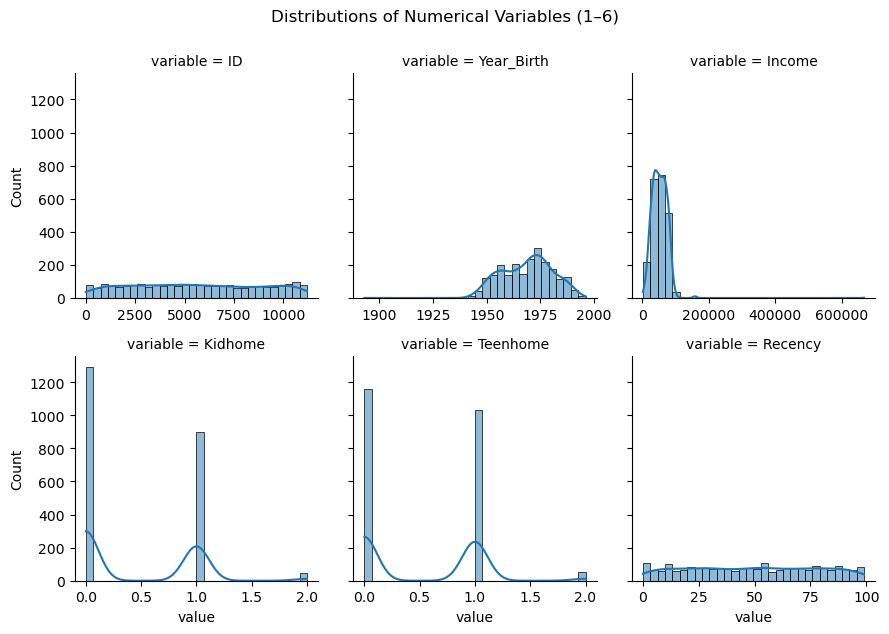

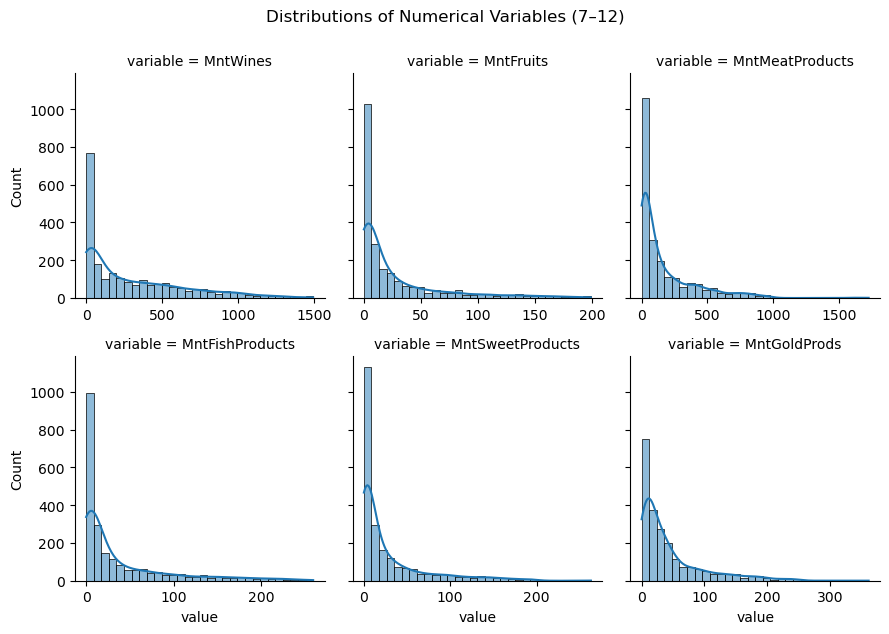

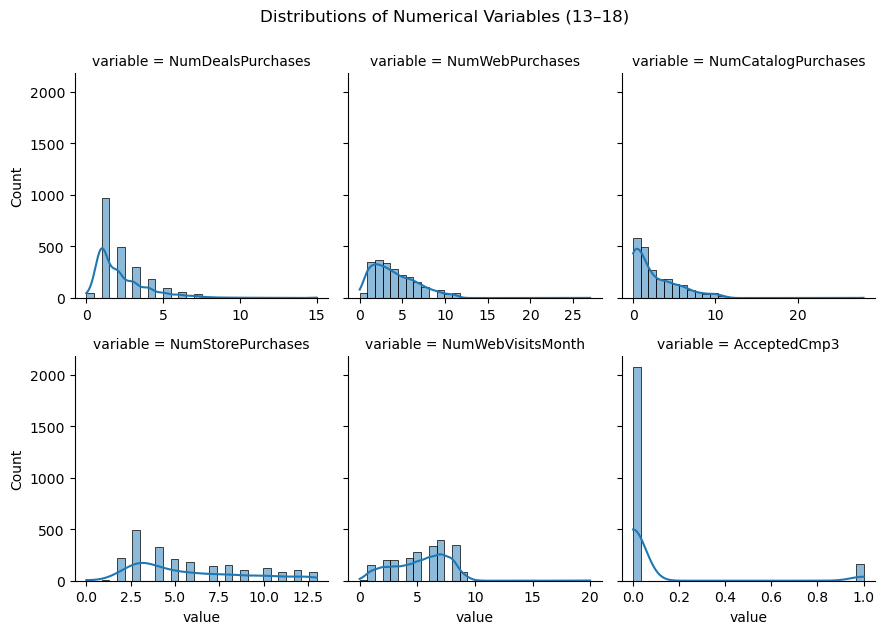

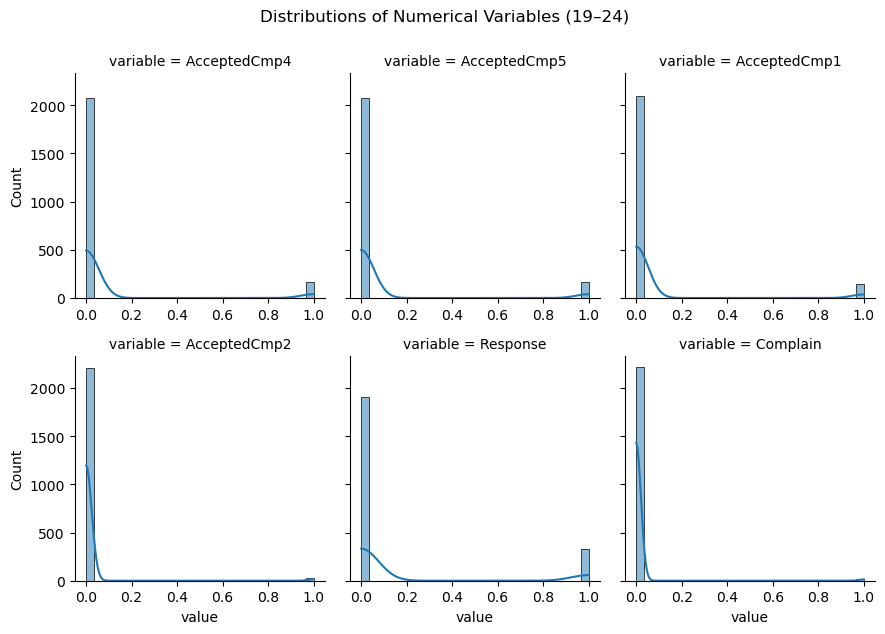

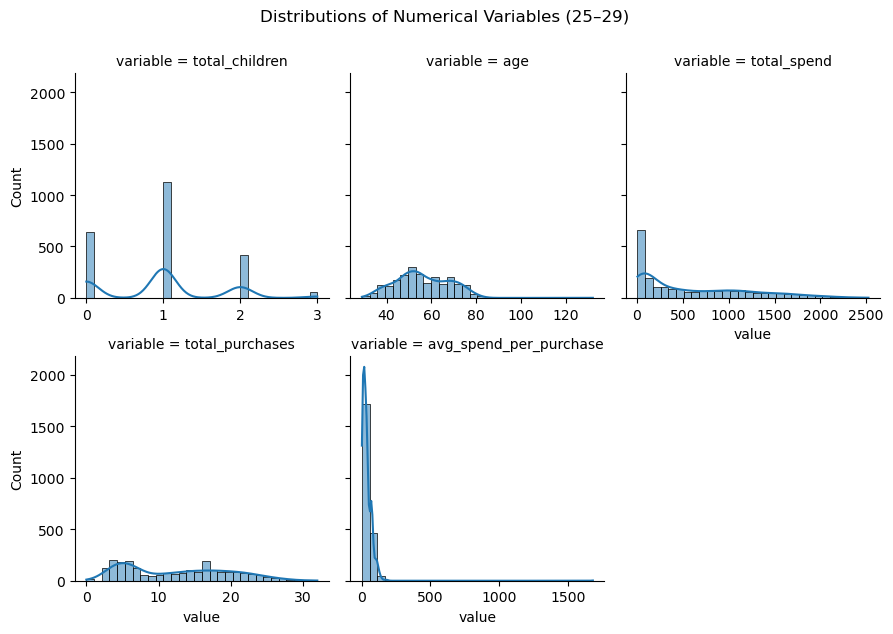

In [47]:
# Facetgrip with pagination for clear layout
cols_per_page = 6
total_cols = len(num_cols)

for i in range(0, total_cols, cols_per_page):
    subset_vars = num_cols[i:i + cols_per_page]
    subset_df = long_df[long_df['variable'].isin(subset_vars)]

    g = sns.FacetGrid(
        subset_df,
        col='variable',
        col_wrap=3,
        sharex=False,
        height=3
    )
    g.map(sns.histplot, 'value', bins=30, kde=True)

    g.fig.suptitle(
        f'Distributions of Numerical Variables ({i+1}–{min(i+cols_per_page, total_cols)})',
        y=1.05
    )
    plt.show()

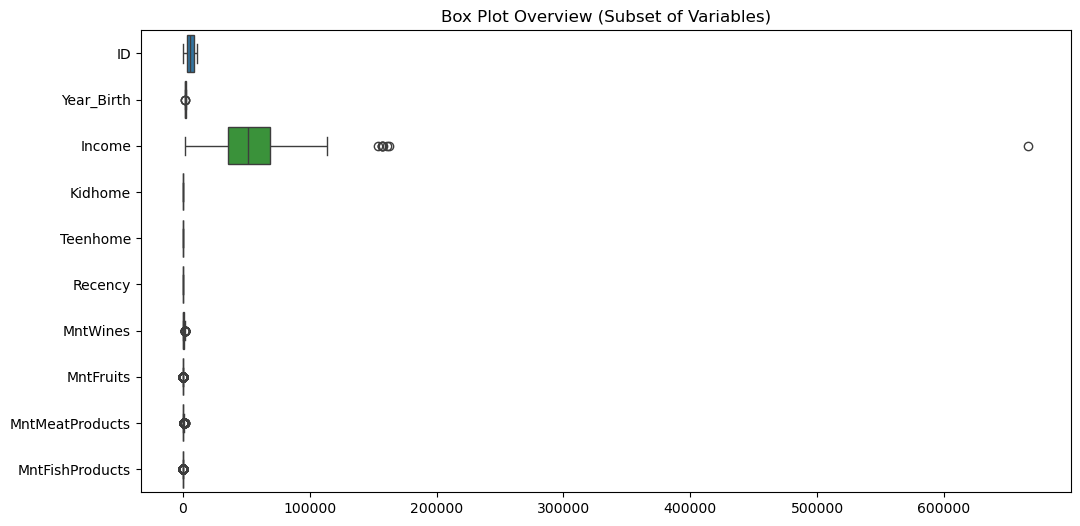

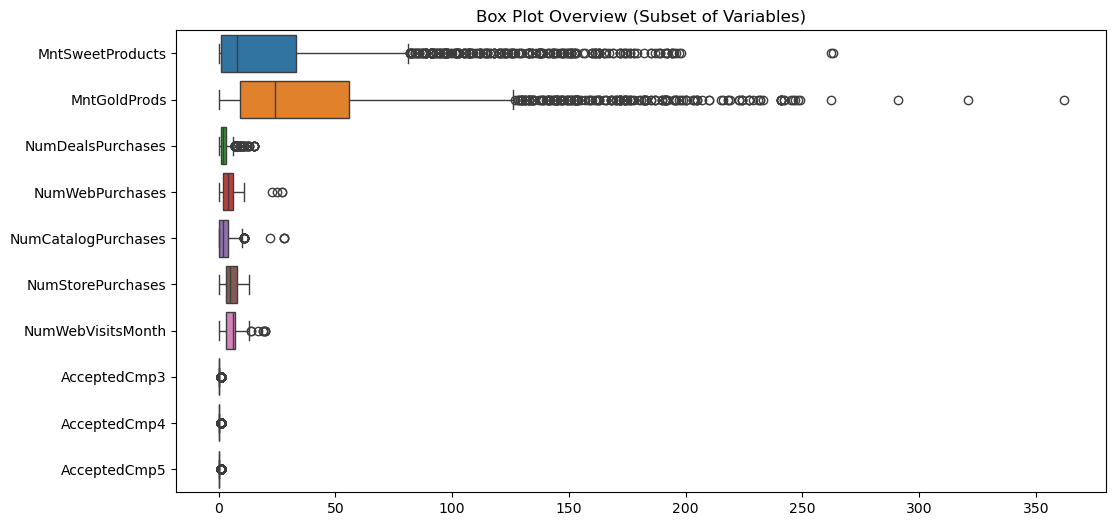

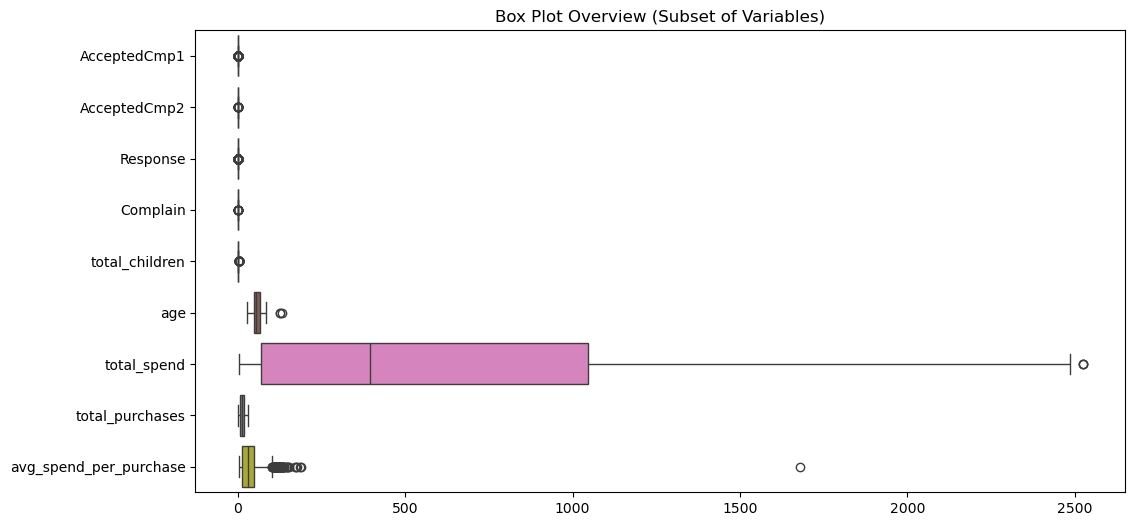

In [46]:
for i in range(0, len(num_cols), 10):
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df[num_cols[i:i+10]], orient='h')
    plt.title('Box Plot Overview (Subset of Variables)')
    plt.show()

# Outlier tratment :
    
    In marketing data :
    - High spenders / high income customers are valid
    - But they distort averages & hypothesis tests

👉 Best practice: cap (winsorize), not remove.

    | Column Type     | Method         | Why                       |
    | --------------- | -------------- | ------------------------- |
    | Income, Spend   | IQR capping    | Robust to skew            |
    | Purchase counts | IQR capping    | Controls extreme behavior |
    | Age             | Logical bounds | Business rules            |
    | Recency         | No treatment   | Meaningful extremes       |
    | Binary          | No treatment   | Invalid to change         |

In [48]:
df.columns = df.columns.str.lower()
# Define col groups
income_spend_cols = [
    'income', 'total_spend', 'avg_spend_per_purchase',
    'mntwines','mntfruits','mntmeatproducts',
    'mntfishproducts','mntsweetproducts','mntgoldprods'
]

purchase_count_cols = [
    'numwebpurchases','numstorepurchases',
    'numcatalogpurchases','numwebvisitsmonth',
    'total_purchases'
]

binary_cols = [
    'acceptedcmp1','acceptedcmp2','acceptedcmp3',
    'acceptedcmp4','acceptedcmp5','response','complain'
]

In [49]:
#IQR Method defining
def iqr_cap(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower=lower, upper=upper)   

In [50]:
df_clean = df.copy()

for col in income_spend_cols + purchase_count_cols:
    df_clean[col] = iqr_cap(df_clean[col])

In [51]:
# Age Handling (Business Logic) Assume age range 18 - 90.
df_clean['age'] = df_clean['age'].clip(lower=18, upper=90)

In [52]:
# Create outliers flag for traceability
for col in income_spend_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[f'{col}_outlier_flag'] = (
        (df[col] < lower) | (df[col] > upper)
    ).astype(int)

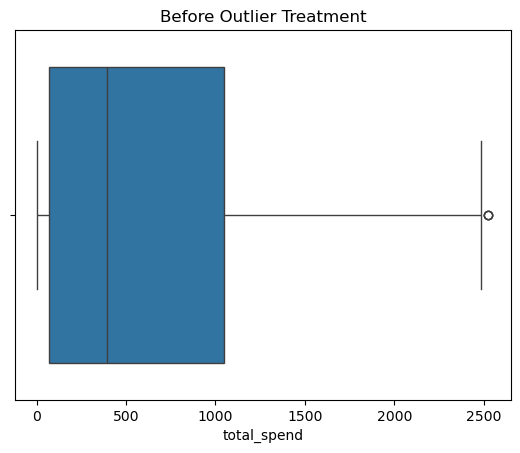

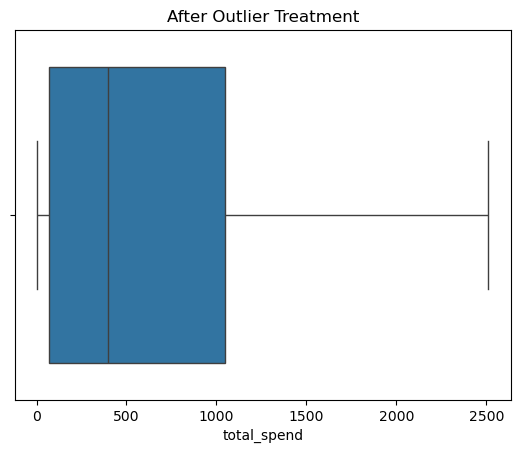

In [53]:
sns.boxplot(x=df['total_spend'])
plt.title('Before Outlier Treatment')
plt.show()

sns.boxplot(x=df_clean['total_spend'])
plt.title('After Outlier Treatment')
plt.show()

### Conclusion:
    - “Given the large number of numerical variables, distributions were visualized in grouped panels using multi-plot layouts. This approach ensured readability while enabling systematic identification of skewness and outliers across all numerical features.”
    - Most numerical variables exhibited strong right-skew and extreme values, particularly in income, spending, and purchase behavior. Since these extreme observations represent valid high-value customers, an IQR-based capping approach was applied instead of row removal. Age was handled using logical bounds, while recency and binary campaign variables were left unchanged due to their business relevance

## Encoding

•	Use ordinal encoding and one hot encoding according to different types of categorical variables.

In [68]:
df_clean.select_dtypes('object').head()

,education,marital_status,country
0,Graduation,Divorced,SP
1,Graduation,Single,CA
2,Graduation,Married,US
3,Graduation,Together,AUS
4,Graduation,Single,SP


In [69]:
# Ordinal encoding
df_clean['education'].unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [70]:
education_order = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}

df_clean['education_encoded'] = df_clean['education'].map(education_order)

In [71]:
# marital_status : one-hot encoding
marital_dummies = pd.get_dummies(
    df_clean['marital_status'],
    prefix='marital',
    drop_first=True
)

df_clean = pd.concat([df_clean, marital_dummies], axis=1)

| Country Count | Best Encoding   |
| ---------- | --------------- |
| ≤ 5 cities | One-Hot         |
| > 5 cities | Target Encoding |

In [78]:
# Country : Target Encoding Value = probability of response from that country. Very powerful for marketing models

#df_clean['country'].unique()
country_target_mean = (
    df_clean.groupby('country')['response']
    .mean()
)

df_clean['country_encoded'] = df_clean['country'].map(country_target_mean)

In [89]:
df_clean.sort_values(by = 'country_encoded', ascending=False)[['country','country_encoded']].drop_duplicates()

,country,country_encoded
149,ME,0.666667
2232,SP,0.160731
2220,SA,0.154303
47,AUS,0.143750
2219,CA,0.141791
51,GER,0.141667
2,US,0.119266
12,IND,0.087838


#####  Conclusion : 
Encoding techniques were selected based on the semantic nature of each categorical variable. Ordinal encoding preserved educational hierarchy, one-hot encoding avoided false order assumptions for marital status, and target encoding efficiently captured country-level response behavior.

# Heatmap : Corr

•	Create a heatmap to showcase the correlation between different pairs of variables.

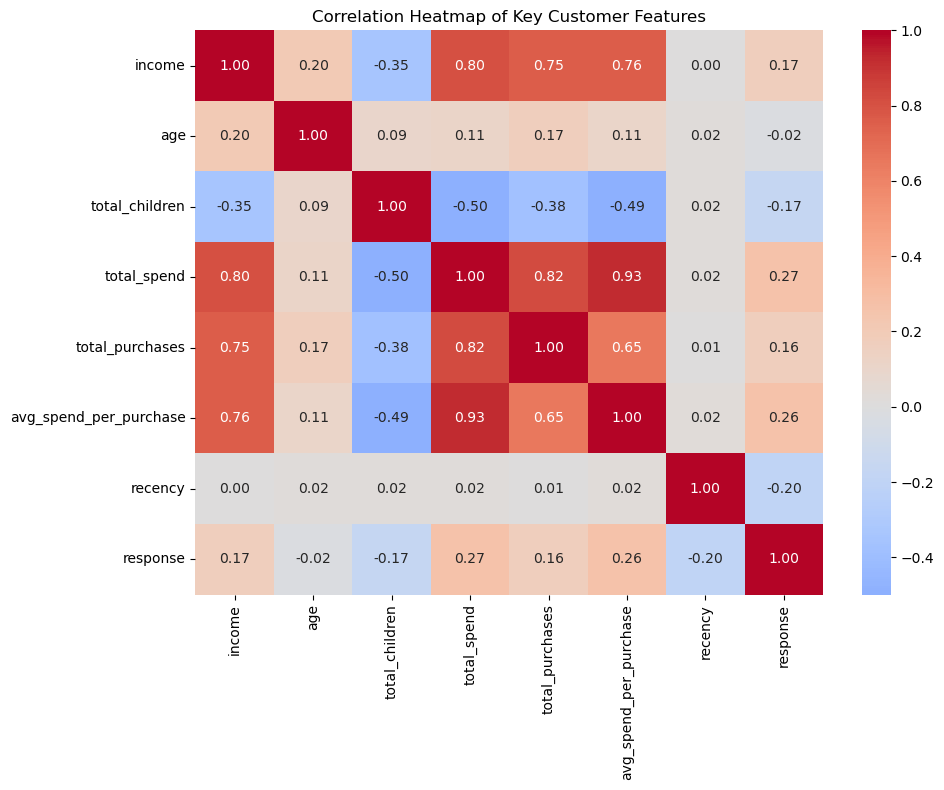

In [54]:
# select numerical columns
focus_cols = [
    'income',
    'age',
    'total_children',
    'total_spend',
    'total_purchases',
    'avg_spend_per_purchase',
    'recency',
    'response'
]

plt.figure(figsize=(10,8))
sns.heatmap(
    df_clean[focus_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Key Customer Features')
plt.tight_layout()
plt.show()


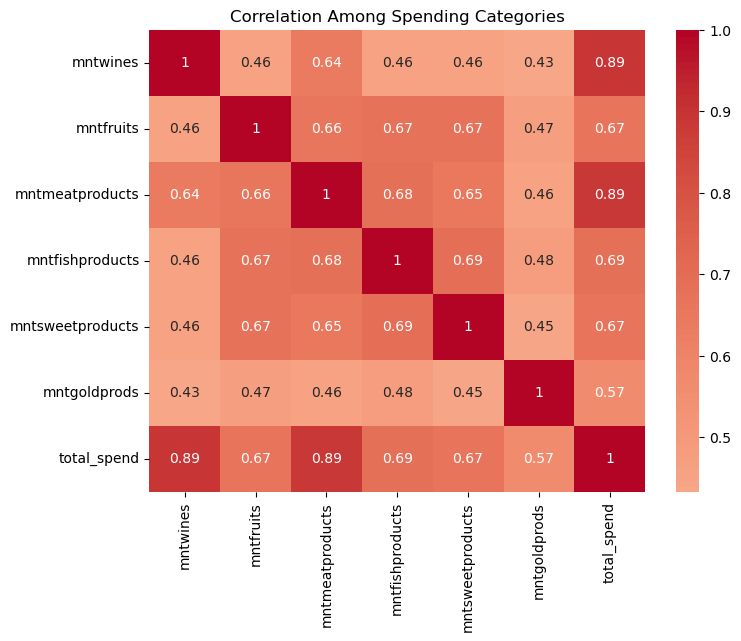

In [56]:
# Spending features
spend_cols = [
    'mntwines','mntfruits','mntmeatproducts',
    'mntfishproducts','mntsweetproducts','mntgoldprods',
    'total_spend'
]

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[spend_cols].corr(), cmap='coolwarm', center=0,annot=True)
plt.title('Correlation Among Spending Categories')
plt.show()

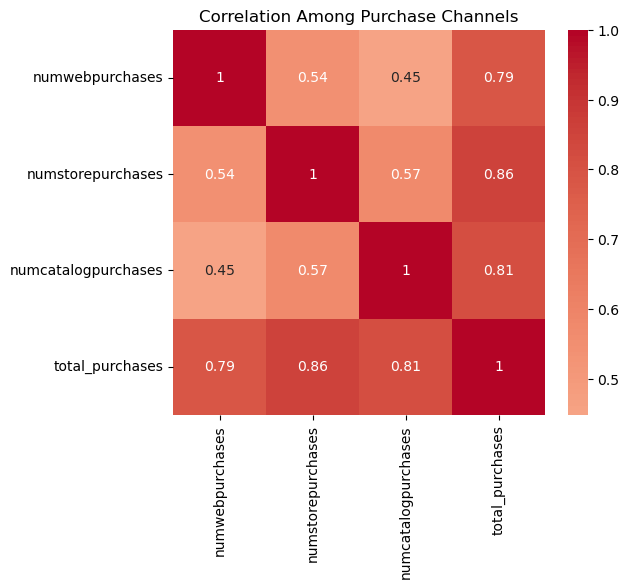

In [57]:
purchase_cols = [
    'numwebpurchases','numstorepurchases',
    'numcatalogpurchases','total_purchases'
]

plt.figure(figsize=(6,5))
sns.heatmap(df_clean[purchase_cols].corr(), cmap='coolwarm', center=0,annot=True)
plt.title('Correlation Among Purchase Channels')
plt.show()


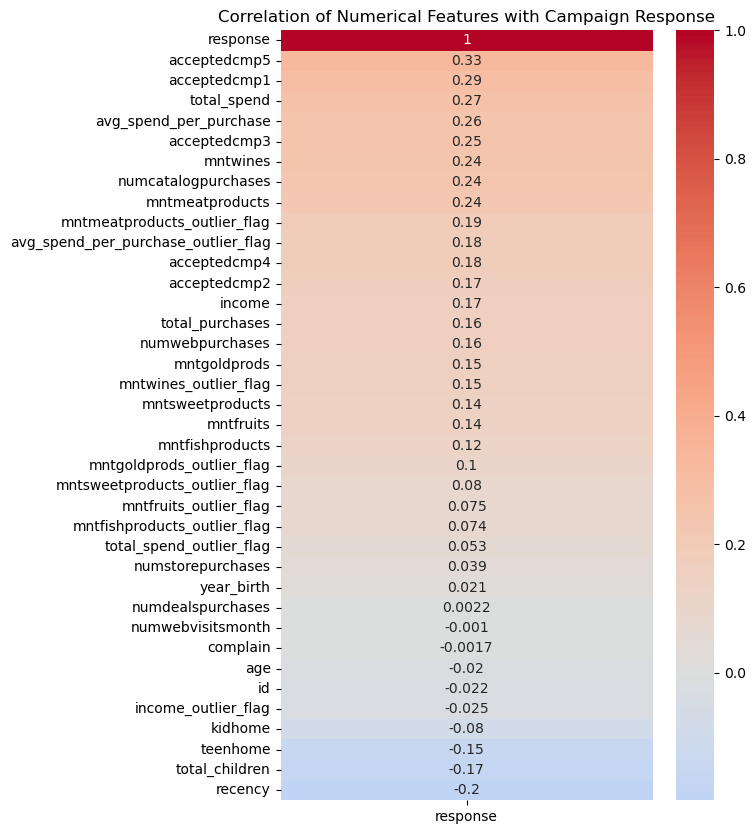

In [59]:
corr_with_target = (
    df_clean.select_dtypes(include='number')
    .corr()['response']
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,10))
sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation of Numerical Features with Campaign Response')
plt.show()

Conclusion : 
“Given the large number of numerical variables, correlation analysis was conducted on selected feature groups and key engineered variables to maintain interpretability. This focused approach enabled clearer insights into relationships most relevant to campaign response.”

# 4. Hypothesis Testing

EDA shows patterns; hypothesis testing validates them.

•	Test the following hypotheses:

    o	Older people are not as tech-savvy and probably prefer shopping in-store.
    o	Customers with kids probably have less time to visit a store and would prefer to shop online.
    o	Other distribution channels may cannibalize sales at the store.
    o	Does the US fare significantly better than the rest of the world in terms of total purchases?


### Test1 - Older people are not as tech-savvy and probably prefer shopping in-store.

Statistical Framing - Compare store purchases vs web purchases across age groups

    H0: The number of in-store purchases does not differ across age groups. # deafult statement consider ther is no imapct or differences
    H1: Older customers make significantly more in-store purchases than younger customers.

In [119]:
# Create Age groups
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[18, 35, 55, 100],
    labels=['Young', 'Middle', 'Senior']
)

In [121]:
store_groups = (
    df_clean
    .groupby('age_group')
    .apply(lambda x: x['numstorepurchases'])
)

In [123]:
store_groups

age_group      
Young      34      3
           108     5
           165     3
           173     8
           190     9
                  ..
Senior     2225    3
           2227    5
           2228    3
           2233    2
           2239    4
Name: numstorepurchases, Length: 2240, dtype: int64

In [126]:
# Hypothesis Testing
stat, p_value = kruskal(*store_groups)

stat, p_value

(np.float64(2238.9999999999995), np.float64(0.496025532838444))

In [127]:
if p_value < 0.05:
    print("Reject H0: Store purchase behavior differs by age group.")
else:
    print("Fail to reject H0: No significant difference by age.")

Fail to reject H0: No significant difference by age.


## Test2️⃣ Hypothesis: Customers with kids prefer online shopping
    H0: Customers with kids and without kids have the same online purchase behavior.
    H1: Customers with kids make more online purchases.

In [129]:
with_kids = df_clean[df_clean['total_children'] > 0] \
                .pipe(lambda x: x['numwebpurchases'])

without_kids = df_clean[df_clean['total_children'] == 0] \
                   .pipe(lambda x: x['numwebpurchases']) # pipe used for clear method chaining

In [132]:
#mannwhitneyu test
stat, p_value = mannwhitneyu(with_kids, without_kids, alternative='greater')

stat, p_value

(np.float64(435870.5), np.float64(0.9999999793379832))

In [133]:
if p_value < 0.05:
    print("Reject H0: Customers with kids prefer online shopping.")
else:
    print("Fail to reject H0.")

Fail to reject H0.


## Test 3️⃣ Hypothesis: Other channels cannibalize store sales
    H0: Store purchases are not negatively related to other channels.
    H1: Web or catalog purchases negatively impact store purchases.

In [134]:
corr_store_web = df_clean[['numstorepurchases','numwebpurchases']] \
    .pipe(lambda x: x.corr().iloc[0,1])

corr_store_catalog = df_clean[['numstorepurchases','numcatalogpurchases']] \
    .pipe(lambda x: x.corr().iloc[0,1])

corr_store_web, corr_store_catalog

(np.float64(0.5433171405788436), np.float64(0.5718496743239273))

In [136]:
if corr_store_web < 0 or corr_store_catalog < 0:
    print("Evidence of channel cannibalization.")
else:
    print("Channels appear complementary.")

Channels appear complementary.


## 4️⃣ Hypothesis: US performs better than rest of the world
    H0: Total purchases in the US are the same as other countries.
    H1: US customers make more total purchases.

In [137]:
us_purchases = df_clean[df_clean['country'] == 'US'] \
                    .pipe(lambda x: x['total_purchases'])

non_us_purchases = df_clean[df_clean['country'] != 'US'] \
                        .pipe(lambda x: x['total_purchases'])

In [138]:
stat, p_value = mannwhitneyu(us_purchases, non_us_purchases, alternative='greater')

stat, p_value

(np.float64(125796.0), np.float64(0.07100997994194977))

In [139]:
if p_value < 0.05:
    print("Reject H0: US customers perform significantly better.")
else:
    print("Fail to reject H0.")


Fail to reject H0.


Conclusion :  
Hypothesis testing was conducted to validate observed behavioral patterns and support data-driven business decisions. The results help identify preferred sales channels across age groups, family structures, and geographies, enabling optimized marketing strategies and resource allocation.

| # | Business Statement                                                       | Variables Involved                               | Test Used                                   | Why This Test Was Chosen                                                                            | Alternative Tests         | Why Alternatives Were Not Used                                                                   |
| - | ------------------------------------------------------------------------ | ------------------------------------------------ | ------------------------------------------- | --------------------------------------------------------------------------------------------------- | ------------------------- | ------------------------------------------------------------------------------------------------ |
| 1 | Older people are not as tech-savvy and probably prefer shopping in-store | Age group (3+ groups), Number of store purchases | **Kruskal–Wallis Test**                     | Compares more than two independent groups; non-parametric; robust to skewed count data and outliers | ANOVA, t-test             | ANOVA and t-test assume normality and equal variances, which are violated in purchase data       |
| 2 | Customers with kids prefer online shopping                               | Kids (Yes/No), Number of web purchases           | **Mann–Whitney U Test**                     | Compares two independent groups; non-parametric; suitable for skewed distributions                  | Independent t-test        | t-test requires normality and is sensitive to outliers                                           |
| 3 | Other distribution channels cannibalize store sales                      | Store purchases vs Web/Catalog purchases         | **Correlation Analysis (Spearman/Pearson)** | Measures direction and strength of relationship; appropriate to detect potential cannibalization    | Regression analysis       | Regression adds complexity and assumptions not required for exploratory cannibalization analysis |
| 4 | US performs better than rest of the world in total purchases             | Country (US vs Non-US), Total purchases          | **Mann–Whitney U Test**                     | Two independent groups; non-parametric; robust to outliers                                          | Independent t-test, ANOVA | Normality assumption not met; ANOVA unnecessary for two groups                                   |


# Visualization

### o 	Which products are performing the best, and which are performing the least in terms of revenue?

In [140]:
# Create product revenue data
product_cols = {
    'mntwines': 'Wines',
    'mntfruits': 'Fruits',
    'mntmeatproducts': 'Meat',
    'mntfishproducts': 'Fish',
    'mntsweetproducts': 'Sweets',
    'mntgoldprods': 'Gold'
}

product_revenue = (
    df_clean[list(product_cols.keys())]
    .sum()
    .rename(product_cols)
    .sort_values(ascending=False)
)

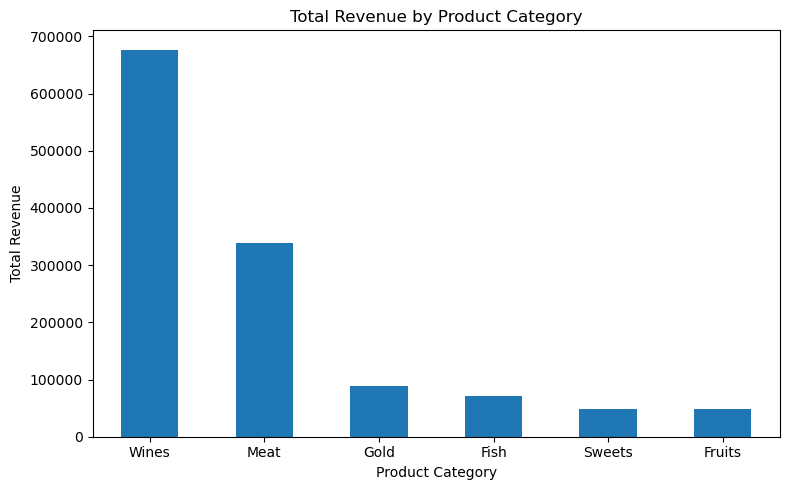

In [143]:
plt.figure(figsize=(8,5))
product_revenue.plot(kind='bar')

plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Wines contribute the highest share of revenue, indicating strong customer preference.

Sweet and fruit products generate comparatively lower revenue, suggesting potential for targeted promotions or product bundling.

### o	Is there any pattern between the age of customers and the last campaign acceptance rate?

In [144]:
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

# calculate acceptance rate
age_acceptance = (
    df_clean
    .groupby('age_group')['response']
    .mean()
)

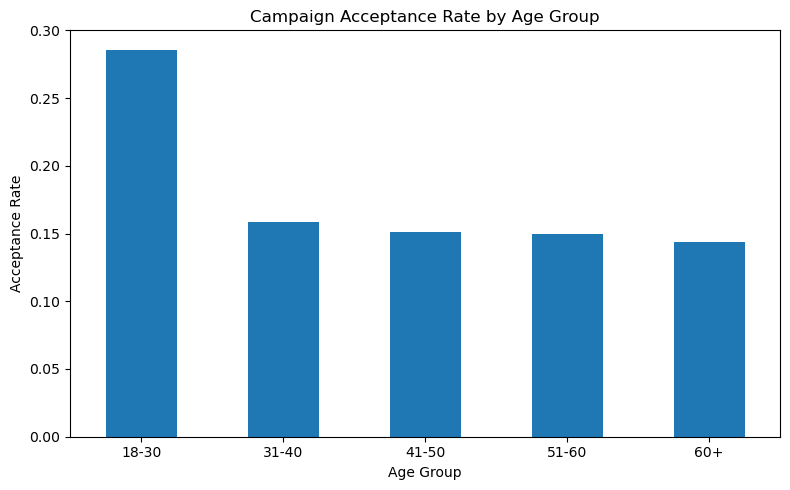

In [145]:
plt.figure(figsize=(8,5))
age_acceptance.plot(kind='bar')

plt.title('Campaign Acceptance Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

“Campaign acceptance rates were analyzed across age groups. Visualization suggests a [positive/negative/no clear] trend between age and acceptance. This pattern was further supported using a non-parametric statistical test.

### o Which Country has the greatest number of customers who accepted the last campaign?

In [146]:
accepted_df = df_clean[df_clean['response'] == 1]

country_acceptance = (
    accepted_df['country']
    .value_counts()
)

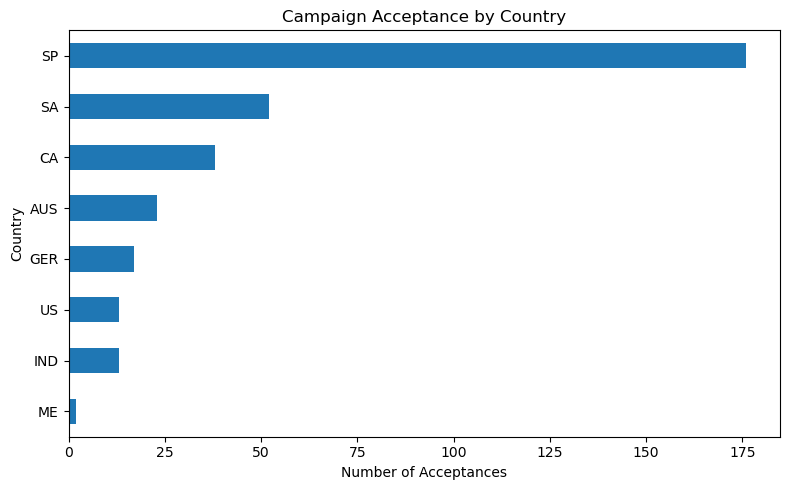

In [149]:
plt.figure(figsize=(8,5))
country_acceptance.sort_values().plot(kind='barh')

plt.title('Campaign Acceptance by Country')
plt.xlabel('Number of Acceptances')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


The number of customers who accepted the last campaign was aggregated by country. The results indicate that <code>SP</code> has the highest number of campaign acceptances, suggesting stronger campaign engagement in this region.

## o	Do you see any pattern in the no. of children at home and total spend?


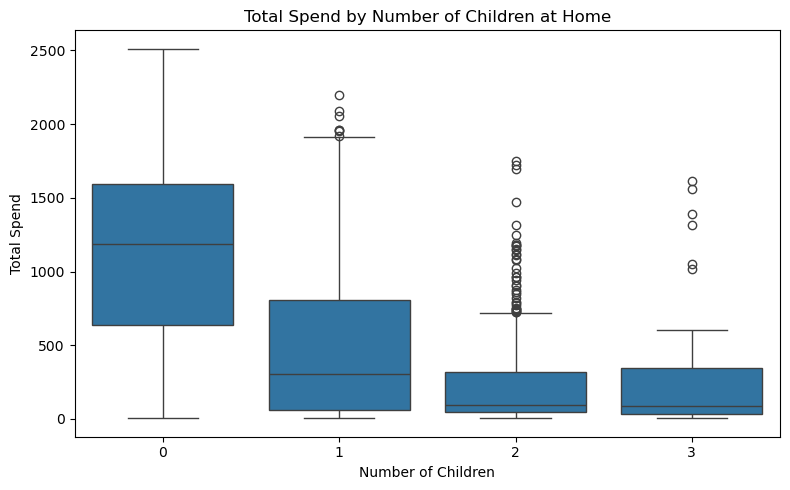

In [151]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x='total_children',
    y='total_spend'
)

plt.title('Total Spend by Number of Children at Home')
plt.xlabel('Number of Children')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()

“Customers with fewer or no children tend to spend more overall, while total spend shows a declining trend as the number of children increases, possibly due to budget constraints

## o	Education background of the customers who complained in the last 2 years.

In [154]:
education_complaints = df_clean['education'].value_counts()

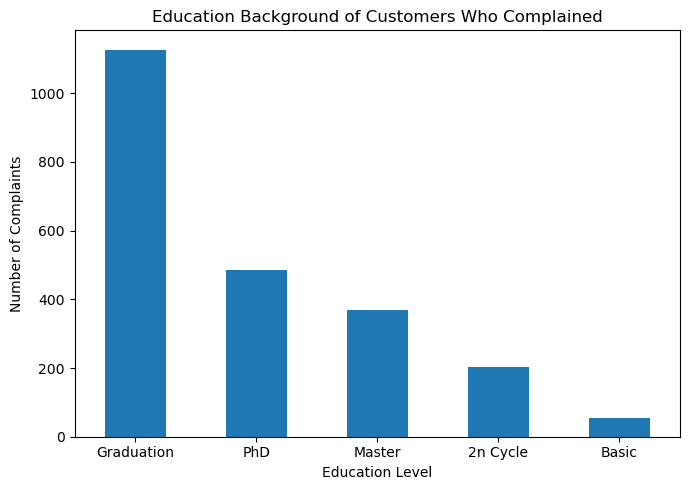

In [155]:
plt.figure(figsize=(7,5))
education_complaints.plot(kind='bar')

plt.title('Education Background of Customers Who Complained')
plt.xlabel('Education Level')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Complaint behavior varies across education levels. Customers with Graduation show a relatively higher complaint rate, indicating differing service expectations or engagement levels.

## Overall Conclusion

This analysis explored customer demographics, purchasing behavior, and campaign response patterns to identify key drivers of customer acquisition. 

Exploratory data analysis revealed that spending and purchase behavior vary meaningfully across age groups, family structure, education level, and geography. Customers with fewer or no children tend to spend more overall, while older customers show the same preference like younger customers for in-store purchases. Product-level analysis indicated that certain categories contribute disproportionately to total revenue, highlighting opportunities for targeted promotions.

Hypothesis testing using robust non-parametric methods validated several observed patterns, including differences in channel preference by age and family status, as well as variation in campaign response across regions. Overall, the findings provide actionable insights for optimizing marketing strategy, channel investment, and customer segmentation, enabling more data-driven and effective campaign planning.